<a href="https://colab.research.google.com/github/amy165/Insurance-Risk-Pricing-Analysis-End-to-End-Project/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Not using Red Flags columns**

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [37]:
model_df=pd.read_csv('modeling_vehicle_insurance_dataset.csv')

In [38]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800996 entries, 0 to 800995
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                800996 non-null  int64  
 1   INSR_BEGIN         800996 non-null  object 
 2   INSR_END           800996 non-null  object 
 3   INSR_TYPE          800996 non-null  int64  
 4   INSURED_VALUE      800996 non-null  float64
 5   PREMIUM            800996 non-null  float64
 6   OBJECT_ID          800996 non-null  int64  
 7   PROD_YEAR          800996 non-null  float64
 8   SEATS_NUM          800996 non-null  float64
 9   CARRYING_CAPACITY  800996 non-null  float64
 10  TYPE_VEHICLE       800996 non-null  object 
 11  CCM_TON            800996 non-null  float64
 12  MAKE               800996 non-null  object 
 13  USAGE              800996 non-null  object 
 14  CLAIM_PAID         800996 non-null  float64
 15  PREMIUM_redflag    800996 non-null  int64  
 16  ha

In [39]:
model_df = model_df.drop(columns=[
    'PREMIUM',
    'PREMIUM_redflag',
    'insured_redflag',
    'CARRYING_redflag',
    'CCM_TON_redflag',
    'SEATS_NUM_redflag,',
    'PROD_YEAR_redflag',
    'INSR_TYPE_redflag',
    'CLAIM_PAID',
    'OBJECT_ID',
    'INSR_BEGIN',
    'INSR_END'
], errors='ignore')

In [40]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800996 entries, 0 to 800995
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                800996 non-null  int64  
 1   INSR_TYPE          800996 non-null  int64  
 2   INSURED_VALUE      800996 non-null  float64
 3   PROD_YEAR          800996 non-null  float64
 4   SEATS_NUM          800996 non-null  float64
 5   CARRYING_CAPACITY  800996 non-null  float64
 6   TYPE_VEHICLE       800996 non-null  object 
 7   CCM_TON            800996 non-null  float64
 8   MAKE               800996 non-null  object 
 9   USAGE              800996 non-null  object 
 10  has_claim          800996 non-null  int64  
 11  begin_year         800996 non-null  int64  
 12  policy_duration    800996 non-null  int64  
 13  SEATS_NUM_redflag  800996 non-null  int64  
 14  vehicle_age        800996 non-null  float64
dtypes: float64(6), int64(6), object(3)
memory usage: 91

In [41]:
model_df.isnull().sum()

,0
SEX,0
INSR_TYPE,0
INSURED_VALUE,0
PROD_YEAR,0
SEATS_NUM,0
CARRYING_CAPACITY,0
TYPE_VEHICLE,0
CCM_TON,0
MAKE,0
USAGE,0


In [42]:
model_df.head()

,SEX,INSR_TYPE,INSURED_VALUE,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,has_claim,begin_year,policy_duration,SEATS_NUM_redflag,vehicle_age
0,0,1202,519755.22,2007.0,4.0,6.0,Pick-Up,3153.0,Nissan,Own Goods,0,2013,364,0,6.0
1,0,1202,519755.22,2007.0,4.0,6.0,Pick-Up,3153.0,Nissan,Own Goods,0,2012,364,0,5.0
2,0,1202,519755.22,2007.0,4.0,6.0,Pick-Up,3153.0,Nissan,Own Goods,0,2011,365,0,4.0
3,0,1202,519755.22,2007.0,4.0,6.0,Pick-Up,3153.0,Nissan,Own Goods,0,2011,30,0,4.0
4,0,1202,285451.24,2010.0,4.0,7.0,Pick-Up,2494.0,Toyota,Own Goods,1,2013,364,0,3.0


In [43]:
model_df.describe()

,SEX,INSR_TYPE,INSURED_VALUE,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,has_claim,begin_year,policy_duration,SEATS_NUM_redflag,vehicle_age
count,800996.000000,800996.000000,8.009960e+05,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000
mean,0.567291,1201.741577,6.924067e+05,2004.528482,6.240313,393.010355,3892.933776,0.075000,2014.676760,351.456644,0.074550,10.151820
std,0.644479,0.439160,8.867114e+05,10.227622,13.373411,3366.598720,3616.833221,0.263392,2.094161,58.758793,0.262664,9.852646
min,0.000000,1201.000000,1.000000e+00,1950.000000,1.000000,1.000000,0.500000,0.000000,2011.000000,1.000000,0.000000,0.000000
25%,0.000000,1201.000000,1.521510e+05,2000.000000,1.000000,6.000000,1296.000000,0.000000,2013.000000,364.000000,0.000000,2.000000
50%,0.000000,1202.000000,4.150000e+05,2008.000000,4.000000,8.000000,2779.000000,0.000000,2015.000000,364.000000,0.000000,7.000000
75%,1.000000,1202.000000,9.589997e+05,2012.000000,4.000000,50.000000,4461.000000,0.000000,2016.000000,364.000000,0.000000,15.000000
max,2.000000,1204.000000,2.500000e+08,2018.000000,199.000000,1000000.000000,20000.000000,1.000000,2018.000000,523.000000,1.000000,68.000000


In [44]:
model_df['MAKE'].value_counts()

,count
MAKE,
Toyota,272451
Isuzu,75602
Bajaji,67267
Nissan,37168
Mitsubishi,22086
...,...
Road-Rpller,1
M 29,1
Scaniya,1


In [45]:
top_makes = model_df['MAKE'].value_counts().nlargest(20).index

model_df['MAKE_grouped'] = model_df['MAKE'].where(
    model_df['MAKE'].isin(top_makes),
    'Other'
)

In [46]:
model_df['vehicle_age'].value_counts()

,count
vehicle_age,
1.0,82388
2.0,71809
3.0,61315
4.0,49988
0.0,48604
...,...
67.0,9
63.0,7
66.0,5


In [47]:
model_df['vehicle_age_group'] = pd.cut(
    model_df['vehicle_age'],
    bins=[0, 3, 10, 20, 100],
    labels=['new', 'young', 'mid', 'old'],
    include_lowest=True
)
model_df['vehicle_age_group'].value_counts()

,count
vehicle_age_group,
new,264116
young,243422
mid,159764
old,133694


In [48]:
model_df['policy_duration_group'] = pd.cut(
    model_df['policy_duration'],
    bins=[0, 60, 200, 370, 600],
    labels=['very_short', 'medium', 'annual', 'long'],
    include_lowest=True
)
model_df['policy_duration_group'].value_counts()

,count
policy_duration_group,
annual,765679
very_short,17826
medium,17459
long,32


In [49]:
model_df['insured_value_group'] = pd.cut(
    model_df['INSURED_VALUE'],
    bins=[0, 100000, 500000, 1000000, 250000000],
    labels=['low', 'medium', 'high', 'very_high'],
    include_lowest=True
)
model_df['insured_value_group'].value_counts()

,count
insured_value_group,
medium,301357
very_high,181293
high,162783
low,155563


In [50]:
model_df.columns

Index(['SEX', 'INSR_TYPE', 'INSURED_VALUE', 'PROD_YEAR', 'SEATS_NUM',
       'CARRYING_CAPACITY', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
       'has_claim', 'begin_year', 'policy_duration', 'SEATS_NUM_redflag',
       'vehicle_age', 'MAKE_grouped', 'vehicle_age_group',
       'policy_duration_group', 'insured_value_group'],
      dtype='object')

In [51]:
num_features = [
    'INSURED_VALUE',
    'PROD_YEAR',
    'SEATS_NUM',
    'CARRYING_CAPACITY',
    'CCM_TON',
    'begin_year',
    'policy_duration',
    'vehicle_age'
]

In [52]:
cat_features = [
    'SEX',
    'INSR_TYPE',
    'TYPE_VEHICLE',
    'USAGE',
    'MAKE_grouped',
    'vehicle_age_group',
    'policy_duration_group',
    'insured_value_group'
]

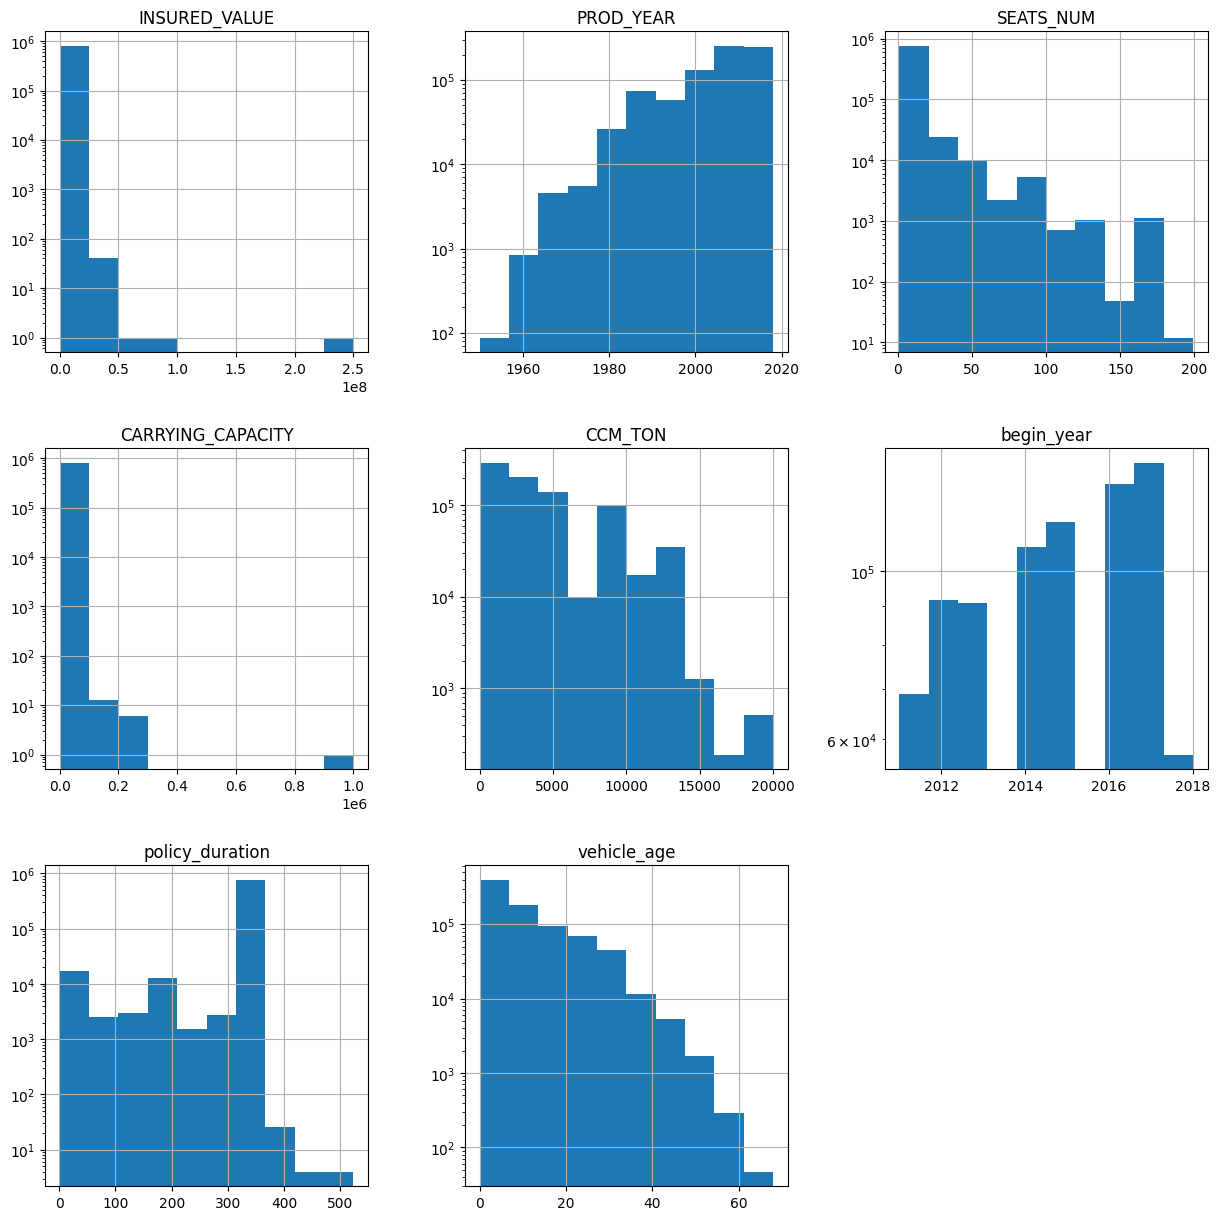

In [53]:
model_df[num_features].hist(figsize=(15,15), log=True)
plt.show()

In [54]:
model_df[num_features].describe()

,INSURED_VALUE,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,begin_year,policy_duration,vehicle_age
count,8.009960e+05,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000
mean,6.924067e+05,2004.528482,6.240313,393.010355,3892.933776,2014.676760,351.456644,10.151820
std,8.867114e+05,10.227622,13.373411,3366.598720,3616.833221,2.094161,58.758793,9.852646
min,1.000000e+00,1950.000000,1.000000,1.000000,0.500000,2011.000000,1.000000,0.000000
25%,1.521510e+05,2000.000000,1.000000,6.000000,1296.000000,2013.000000,364.000000,2.000000
50%,4.150000e+05,2008.000000,4.000000,8.000000,2779.000000,2015.000000,364.000000,7.000000
75%,9.589997e+05,2012.000000,4.000000,50.000000,4461.000000,2016.000000,364.000000,15.000000
max,2.500000e+08,2018.000000,199.000000,1000000.000000,20000.000000,2018.000000,523.000000,68.000000


In [55]:
model_df[model_df['CARRYING_CAPACITY']>200000]

,SEX,INSR_TYPE,INSURED_VALUE,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,has_claim,begin_year,policy_duration,SEATS_NUM_redflag,vehicle_age,MAKE_grouped,vehicle_age_group,policy_duration_group,insured_value_group
34256,0,1202,376062.24,2002.0,4.0,1000000.0,Pick-Up,2892.0,Ford,Own Goods,0,2011,365,1,9.0,Ford,young,annual,medium
224799,1,1202,250000.00,1996.0,1.0,224000.0,Trailers And Semitrailers,9726.0,Maru,General Cartage,0,2013,364,1,17.0,Other,mid,annual,medium
224800,1,1202,300000.00,1996.0,1.0,224000.0,Trailers And Semitrailers,9726.0,Maru,General Cartage,0,2012,364,1,16.0,Other,mid,annual,medium
460490,1,1202,250000.00,1996.0,1.0,224000.0,Trailers And Semitrailers,9726.0,Maru,General Cartage,0,2017,364,1,21.0,Other,old,annual,medium
460491,1,1202,250000.00,1996.0,1.0,224000.0,Trailers And Semitrailers,9726.0,Maru,General Cartage,0,2016,364,1,20.0,Other,mid,annual,medium
460492,1,1202,250000.00,1996.0,1.0,224000.0,Trailers And Semitrailers,9726.0,Maru,General Cartage,0,2015,365,1,19.0,Other,mid,annual,medium
460493,1,1202,250000.00,1996.0,1.0,224000.0,Trailers And Semitrailers,9726.0,Maru,General Cartage,0,2014,364,1,18.0,Other,mid,annual,medium


In [56]:
model_df['INSURED_VALUE_log'] = np.log1p(model_df['INSURED_VALUE'])
model_df['CARRYING_CAPACITY_log'] = np.log1p(model_df['CARRYING_CAPACITY'])

In [57]:
num_features_logistic = [
    'INSURED_VALUE_log',
    'CARRYING_CAPACITY_log',
    'SEATS_NUM',
    'CCM_TON',
    'PROD_YEAR',
    'begin_year',
    'policy_duration',
    'vehicle_age'
]

In [58]:
num_features_tree = [
    'INSURED_VALUE',
    'CARRYING_CAPACITY',
    'SEATS_NUM',
    'CCM_TON',
    'PROD_YEAR',
    'begin_year',
    'policy_duration',
    'vehicle_age'
]

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

In [60]:
X_log = model_df[num_features_logistic + cat_features]
y = model_df['has_claim']

**Logistic Regression Model**

In [61]:
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [62]:
X_log_train = pd.get_dummies(X_log_train, drop_first=True)
X_log_test = pd.get_dummies(X_log_test, drop_first=True)

#asegurar X_train y X_test tengan columnas en mismo orden
X_log_test = X_log_test.reindex(columns=X_log_train.columns, fill_value=0)

In [63]:
print(X_log_train.shape, X_log_test.shape)

(640796, 62) (160200, 62)


In [64]:
model_LR=LogisticRegression(max_iter=1000)
model_LR.fit(X_log_train, y_log_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [65]:
y_pred_LR = model_LR.predict(X_log_test)
y_prob_LR = model_LR.predict_proba(X_log_test)[:,1]

print(classification_report(y_log_test, y_pred_LR))
print("ROC-AUC:", roc_auc_score(y_log_test, y_prob_LR))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96    148185
           1       0.00      0.00      0.00     12015

    accuracy                           0.92    160200
   macro avg       0.46      0.50      0.48    160200
weighted avg       0.86      0.92      0.89    160200

ROC-AUC: 0.7108585983618597


**Logistic Regression Model Balanced**

In [66]:
model_LR_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_LR_balanced.fit(X_log_train, y_log_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [67]:
y_pred_LR_balanced = model_LR_balanced.predict(X_log_test)
y_prob_LR_balanced = model_LR_balanced.predict_proba(X_log_test)[:,1]

print(classification_report(y_log_test, y_pred_LR_balanced))
print("ROC-AUC:", roc_auc_score(y_log_test, y_prob_LR_balanced))
print("PR-AUC:", average_precision_score(y_tree_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.97      0.54      0.69    148185
           1       0.12      0.78      0.21     12015

    accuracy                           0.56    160200
   macro avg       0.54      0.66      0.45    160200
weighted avg       0.90      0.56      0.66    160200

ROC-AUC: 0.7133070387505153
PR-AUC: 0.1837715560352677


In [68]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_LR_balanced > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_log_test, y_pred_t))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.24      0.39    148185
           1       0.09      0.98      0.17     12015

    accuracy                           0.30    160200
   macro avg       0.54      0.61      0.28    160200
weighted avg       0.92      0.30      0.37    160200


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.29      0.45    148185
           1       0.10      0.96      0.18     12015

    accuracy                           0.34    160200
   macro avg       0.54      0.62      0.31    160200
weighted avg       0.92      0.34      0.43    160200


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.38      0.55    148185
           1       0.11      0.91      0.19     12015

    accuracy                           0.42    160200
   macro avg       0.54      0.65      0.37    160200
weighted avg       0.92   

**Random Forest Model**

In [69]:
X_tree = model_df[num_features_tree + cat_features]
y = model_df['has_claim']

In [70]:
X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [71]:
X_tree_train = pd.get_dummies(X_tree_train, drop_first=True)
X_tree_test = pd.get_dummies(X_tree_test, drop_first=True)

#asegurar X_train y X_test tengan columnas en mismo orden
X_tree_test = X_tree_test.reindex(columns=X_tree_train.columns, fill_value=0)

In [72]:
print(X_tree_train.shape, X_tree_test.shape)

(640796, 62) (160200, 62)


In [73]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_rf.fit(X_tree_train, y_tree_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [74]:
y_prob_rf = model_rf.predict_proba(X_tree_test)[:,1]
y_pred_rf = model_rf.predict(X_tree_test)

print(classification_report(y_tree_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_tree_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_tree_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92    148185
           1       0.19      0.29      0.23     12015

    accuracy                           0.85    160200
   macro avg       0.56      0.59      0.57    160200
weighted avg       0.88      0.85      0.87    160200

ROC-AUC: 0.6968425699612839
PR-AUC: 0.1837715560352677


**Random Forest Model n_estimators=200 max_depth=10**

In [75]:
model_rf_md10 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model_rf_md10.fit(X_tree_train, y_tree_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [76]:
y_prob_rf_md10 = model_rf_md10.predict_proba(X_tree_test)[:,1]
y_pred_rf_md10 = model_rf_md10.predict(X_tree_test)

print(classification_report(y_tree_test, y_pred_rf_md10))
print("ROC-AUC:", roc_auc_score(y_tree_test, y_prob_rf_md10))
print("PR-AUC:", average_precision_score(y_tree_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.97      0.55      0.70    148185
           1       0.13      0.81      0.22     12015

    accuracy                           0.57    160200
   macro avg       0.55      0.68      0.46    160200
weighted avg       0.91      0.57      0.67    160200

ROC-AUC: 0.7480953632446851
PR-AUC: 0.1837715560352677


In [77]:
importances_rf = pd.Series(model_rf_md10.feature_importances_, index=X_tree_train.columns)
importances_rf.sort_values(ascending=False).head(15)

,0
INSURED_VALUE,0.150749
TYPE_VEHICLE_Motor-Cycle,0.118947
CCM_TON,0.115321
CARRYING_CAPACITY,0.098716
SEATS_NUM,0.064436
vehicle_age,0.051210
PROD_YEAR,0.046625
MAKE_grouped_Bajaji,0.040401
policy_duration,0.039780
vehicle_age_group_old,0.022989


**XGBoost Model**

In [79]:
scale_pos_weight = (y_tree_train == 0).sum() / (y_tree_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_tree_train, y_tree_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:00:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
y_pred_xgb = model_xgb.predict(X_tree_test)
y_prob_xgb = model_xgb.predict_proba(X_tree_test)[:, 1]

print(classification_report(y_tree_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_tree_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_tree_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.97      0.60      0.74    148185
           1       0.14      0.78      0.23     12015

    accuracy                           0.62    160200
   macro avg       0.55      0.69      0.49    160200
weighted avg       0.91      0.62      0.71    160200

ROC-AUC: 0.7605789208810714
PR-AUC: 0.18932462277620288


In [81]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_xgb_t = (y_prob_xgb > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_tree_test, y_pred_xgb_t))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.27      0.42    148185
           1       0.10      0.98      0.18     12015

    accuracy                           0.32    160200
   macro avg       0.55      0.62      0.30    160200
weighted avg       0.93      0.32      0.41    160200


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.35      0.52    148185
           1       0.11      0.96      0.19     12015

    accuracy                           0.39    160200
   macro avg       0.55      0.65      0.35    160200
weighted avg       0.92      0.39      0.49    160200


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.45      0.62    148185
           1       0.12      0.90      0.21     12015

    accuracy                           0.49    160200
   macro avg       0.55      0.68      0.41    160200
weighted avg       0.92   

In [82]:
importances_xgb = pd.Series(model_xgb.feature_importances_, index=X_tree_train.columns)
importances_xgb.sort_values(ascending=False).head(15)

,0
TYPE_VEHICLE_Motor-Cycle,0.628800
TYPE_VEHICLE_Tractor,0.036064
TYPE_VEHICLE_Trailers And Semitrailers,0.026508
USAGE_General Cartage,0.023075
policy_duration,0.018295
INSURED_VALUE,0.017822
SEATS_NUM,0.017134
MAKE_grouped_Oral,0.013749
vehicle_age,0.013242
MAKE_grouped_Other,0.011302


**Exporting Data**

In [83]:
print("Missing values in X_log:", X_log.isna().sum().sum())
print("Missing values in X_tree:", X_tree.isna().sum().sum())
print("Target distribution:")
print(y.value_counts(normalize=True))

Missing values in X_log: 0
Missing values in X_tree: 0
Target distribution:
has_claim
0    0.925
1    0.075
Name: proportion, dtype: float64


In [84]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, average_precision_score
)

def get_metrics(model_name, y_true, y_pred, y_prob, threshold=None):
    return {
        'model': model_name,
        'threshold': threshold,
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_claims': precision_score(y_true, y_pred, pos_label=1),
        'recall_claims': recall_score(y_true, y_pred, pos_label=1),
        'f1_claims': f1_score(y_true, y_pred, pos_label=1)
    }

model_results = []

model_results.append(get_metrics(
    'Logistic Regression',
    y_log_test,
    y_pred_LR,
    y_prob_LR,
    threshold=0.5
))

model_results.append(get_metrics(
    'Logistic Regression Balanced',
    y_log_test,
    y_pred_LR_balanced,
    y_prob_LR_balanced,
    threshold=0.5
))

model_results.append(get_metrics(
    'Random Forest',
    y_tree_test,
    y_pred_rf,
    y_prob_rf,
    threshold=0.5
))

model_results.append(get_metrics(
    'Random Forest Tuned',
    y_tree_test,
    y_pred_rf_md10,
    y_prob_rf_md10,
    threshold=0.5
))

model_results.append(get_metrics(
    'XGBoost',
    y_tree_test,
    y_pred_xgb,
    y_prob_xgb,
    threshold=0.5
))

model_results_df = pd.DataFrame(model_results)
model_results_df

,model,threshold,roc_auc,pr_auc,accuracy,precision_claims,recall_claims,f1_claims
0,Logistic Regression,0.5,0.710859,0.144066,0.924969,0.000000,0.000000,0.000000
1,Logistic Regression Balanced,0.5,0.713307,0.143686,0.559095,0.120978,0.778610,0.209418
2,Random Forest,0.5,0.696843,0.167757,0.853895,0.189703,0.289804,0.229305
3,Random Forest Tuned,0.5,0.748095,0.176824,0.570949,0.127960,0.811819,0.221074
4,XGBoost,0.5,0.760579,0.189325,0.615830,0.137898,0.784935,0.234584


In [85]:
model_results_df.to_csv('model_results.csv', index=False)

In [86]:
threshold_results = []

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_xgb > t).astype(int)

    threshold_results.append({
        'model': 'XGBoost',
        'threshold': t,
        'precision_claims': precision_score(y_tree_test, y_pred_t, pos_label=1),
        'recall_claims': recall_score(y_tree_test, y_pred_t, pos_label=1),
        'f1_claims': f1_score(y_tree_test, y_pred_t, pos_label=1),
        'accuracy': accuracy_score(y_tree_test, y_pred_t)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,model,threshold,precision_claims,recall_claims,f1_claims,accuracy
0,XGBoost,0.2,0.097839,0.975947,0.177849,0.323265
1,XGBoost,0.3,0.106394,0.955306,0.191464,0.394875
2,XGBoost,0.4,0.117962,0.903371,0.208675,0.486142
3,XGBoost,0.5,0.137898,0.784935,0.234584,0.615830


In [87]:
threshold_results_df.to_csv('xgboost_threshold_results.csv', index=False)

In [110]:
xgb_importance_df = (
    pd.Series(model_xgb.feature_importances_, index=X_tree_train.columns)
    .sort_values(ascending=False)
    .reset_index()
)

xgb_importance_df.columns = ['feature', 'importance']

xgb_importance_df.head(20)

,feature,importance
0,TYPE_VEHICLE_Motor-Cycle,0.628800
1,TYPE_VEHICLE_Tractor,0.036064
2,TYPE_VEHICLE_Trailers And Semitrailers,0.026508
3,USAGE_General Cartage,0.023075
4,policy_duration,0.018295
5,INSURED_VALUE,0.017822
6,SEATS_NUM,0.017134
7,MAKE_grouped_Oral,0.013749
8,vehicle_age,0.013242
9,MAKE_grouped_Other,0.011302


In [111]:
rename_dict = {
    'TYPE_VEHICLE_Motor-Cycle': 'Motor-Cycle',
    'TYPE_VEHICLE_Tractor': 'Tractor',
    'TYPE_VEHICLE_Truck': 'Truck',
    'TYPE_VEHICLE_Bus': 'Bus',
    'TYPE_VEHICLE_Trailers And Semitrailers': 'Trailer',

    'USAGE_General Cartage': 'Usage: Cartage',
    'USAGE_Own Goods': 'Usage: Own Goods',
    'USAGE_Fare Paying Passengers': 'Usage: Passengers',
    'USAGE_Ambulance': 'Usage: Ambulance',

    'MAKE_grouped_Toyota': 'Toyota',
    'MAKE_grouped_Oral': 'Oral',
    'MAKE_grouped_Other': 'Other Make',

    'INSURED_VALUE': 'Insured Value',
    'insured_value_group_very_high': 'Value: Very High',

    'SEATS_NUM': 'Seats',
    'SEATS_NUM_redflag': 'Seats Missing',

    'CARRYING_CAPACITY': 'Carrying Cap.',
    'CCM_TON': 'Engine Size',

    'vehicle_age': 'Vehicle Age',
    'vehicle_age_group_old': 'Old Vehicles',

    'policy_duration': 'Duration',
    'policy_duration_group_annual': 'Annual Policy',
    'policy_duration_group_medium': 'Mid Duration'
}

In [112]:
xgb_importance_df['feature_clean'] = xgb_importance_df['feature'].map(rename_dict)
xgb_importance_df['feature_clean'] = xgb_importance_df['feature_clean'].fillna(xgb_importance_df['feature'])
xgb_importance_df = xgb_importance_df.drop(columns=['feature'])
xgb_importance_df = xgb_importance_df.rename(columns={'feature_clean': 'feature'})

xgb_importance_df.head(10)

,importance,feature
0,0.628800,Motor-Cycle
1,0.036064,Tractor
2,0.026508,Trailer
3,0.023075,Usage: Cartage
4,0.018295,Duration
5,0.017822,Insured Value
6,0.017134,Seats
7,0.013749,Oral
8,0.013242,Vehicle Age
9,0.011302,Other Make


In [113]:
xgb_importance_df.to_csv('xgboost_feature_importance.csv', index=False)

In [90]:
rf_importance_df = (
    pd.Series(model_rf_md10.feature_importances_, index=X_tree_train.columns)
    .sort_values(ascending=False)
    .reset_index()
)

rf_importance_df.columns = ['feature', 'importance']

rf_importance_df.to_csv('rf_feature_importance.csv', index=False)

In [91]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_tree_test, y_pred_xgb)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

cm_long = cm_df.reset_index().melt(id_vars='index')
cm_long.columns = ['Actual', 'Predicted', 'Count']

cm_long.to_csv('confusion_matrix_xgb.csv', index=False)